# Feature Engineering for Ames Housing

This notebook covers:
1. Creating new features from existing ones
2. Handling categorical variables (FULL ENCODING)
3. Feature transformation
4. Feature selection with proper NaN handling

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import json
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Create directories if they don't exist
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

print("✅ Directories ready")

✅ Directories ready


In [47]:
# Load the raw data
df = pd.read_csv('../data/raw/AmesHousing.csv')
print(f'Original dataset shape: {df.shape}')
df.head()

Original dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 1. Data Cleaning Function (with proper NaN handling)

In [48]:
def clean_ames_data(data):
    """Clean the Ames Housing dataset with proper NaN handling."""
    df_clean = data.copy()
    
    # Remove ID columns
    id_cols = [col for col in df_clean.columns if 'id' in col.lower() or 'pid' in col.lower()]
    if id_cols:
        df_clean = df_clean.drop(columns=id_cols)
        print(f"Removed ID columns: {id_cols}")
    
    # Handle categorical missing values
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna('NA')
            print(f"Filled missing in {col} with 'NA'")
    
    # Handle numerical missing values
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != 'SalePrice']
    
    dropped_cols = []
    for col in numeric_cols:
        missing_pct = df_clean[col].isnull().mean()
        if missing_pct > 0.5:
            # Drop columns with >50% missing
            df_clean = df_clean.drop(columns=[col])
            dropped_cols.append(col)
        elif missing_pct > 0:
            # Fill with median for remaining columns
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            print(f"Filled missing in {col} with median: {median_val:.2f}")
    
    if dropped_cols:
        print(f"Dropped columns with >50% missing: {dropped_cols}")
    
    print(f"Cleaned shape: {df_clean.shape}")
    print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
    return df_clean

# Clean the data
df_clean = clean_ames_data(df)
print(f"\n✅ Cleaning complete. Shape: {df_clean.shape}")

Removed ID columns: ['PID']
Filled missing in Alley with 'NA'
Filled missing in Mas Vnr Type with 'NA'
Filled missing in Bsmt Qual with 'NA'
Filled missing in Bsmt Cond with 'NA'
Filled missing in Bsmt Exposure with 'NA'
Filled missing in BsmtFin Type 1 with 'NA'
Filled missing in BsmtFin Type 2 with 'NA'
Filled missing in Electrical with 'NA'
Filled missing in Fireplace Qu with 'NA'
Filled missing in Garage Type with 'NA'
Filled missing in Garage Finish with 'NA'
Filled missing in Garage Qual with 'NA'
Filled missing in Garage Cond with 'NA'
Filled missing in Pool QC with 'NA'
Filled missing in Fence with 'NA'
Filled missing in Misc Feature with 'NA'
Filled missing in Lot Frontage with median: 68.00
Filled missing in Mas Vnr Area with median: 0.00
Filled missing in BsmtFin SF 1 with median: 370.00
Filled missing in BsmtFin SF 2 with median: 0.00
Filled missing in Bsmt Unf SF with median: 466.00
Filled missing in Total Bsmt SF with median: 990.00
Filled missing in Bsmt Full Bath with m

## 2. Create New Features

In [49]:
def create_features(df):
    """Create new features from existing data."""
    df_new = df.copy()
    
    # 1. Age features
    df_new['Age'] = df_new['Yr Sold'] - df_new['Year Built']
    df_new['Age_At_Remodel'] = df_new['Year Remod/Add'] - df_new['Year Built']
    df_new['Is_Remodeled'] = (df_new['Age_At_Remodel'] > 0).astype(int)
    # NOTE: Age_Group will be encoded as numeric below
    df_new['Age_Group_New'] = pd.cut(df_new['Age'], bins=[0, 10, 25, 50, 100, 200], 
                                     labels=[0, 1, 2, 3, 4])
    df_new['Age_Group_New'] = df_new['Age_Group_New'].astype('Int64')
    
    # 2. Area features
    df_new['Total_SF'] = df_new['1st Flr SF'] + df_new['2nd Flr SF']
    df_new['Total_Basement_SF'] = df_new['Total Bsmt SF']
    df_new['Total_Area'] = df_new['Total_SF'] + df_new['Total_Basement_SF']
    df_new['Lot_Area_Acres'] = df_new['Lot Area'] / 43560
    df_new['SF_per_Lot'] = df_new['Total_Area'] / (df_new['Lot Area'] + 1)
    df_new['Has_2nd_Floor'] = (df_new['2nd Flr SF'] > 0).astype(int)
    df_new['Has_Basement'] = (df_new['Total_Basement_SF'] > 0).astype(int)
    
    # 3. Room features
    df_new['Total_Bathrooms'] = (df_new['Bsmt Full Bath'] + 
                                df_new['Bsmt Half Bath'] * 0.5 + 
                                df_new['Full Bath'] + 
                                df_new['Half Bath'] * 0.5)
    df_new['Total_Rooms'] = df_new['TotRms AbvGrd'] + df_new['Bedroom AbvGr']
    df_new['Bedroom_Per_Room'] = df_new['Bedroom AbvGr'] / (df_new['TotRms AbvGrd'] + 1)
    df_new['Bathroom_Per_Room'] = df_new['Total_Bathrooms'] / (df_new['TotRms AbvGrd'] + 1)
    
    # 4. Porch/Outdoor features
    df_new['Total_Porch_SF'] = (df_new['Wood Deck SF'] + 
                               df_new['Open Porch SF'] + 
                               df_new['Enclosed Porch'] + 
                               df_new['3Ssn Porch'] + 
                               df_new['Screen Porch'])
    df_new['Has_Porch'] = (df_new['Total_Porch_SF'] > 0).astype(int)
    df_new['Has_Pool'] = (df_new['Pool Area'] > 0).astype(int)
    df_new['Has_Fireplace'] = (df_new['Fireplaces'] > 0).astype(int)
    
    # 5. Garage features
    df_new['Has_Garage'] = (df_new['Garage Area'] > 0).astype(int)
    df_new['Garage_Cars_Per_Area'] = df_new['Garage Cars'] / (df_new['Garage Area'] + 1) * 100
    
    # 6. Quality features
    df_new['Quality_Score'] = df_new['Overall Qual'] * df_new['Overall Cond']
    df_new['Quality_Per_Room'] = df_new['Overall Qual'] / (df_new['TotRms AbvGrd'] + 1)
    
    # 7. Sale features
    df_new['Is_New_Construction'] = (df_new['Sale Condition'] == 'New').astype(int)
    df_new['Is_Family_Sale'] = (df_new['Sale Condition'] == 'Family').astype(int)
    df_new['Is_Abnormal_Sale'] = (df_new['Sale Condition'].isin(['Abnorml', 'AdjLand', 'Alloca'])).astype(int)
    df_new['Sale_Year_Month'] = df_new['Yr Sold'] * 12 + df_new['Mo Sold']
    
    # 8. Neighborhood features
    neighborhood_price = df_new.groupby('Neighborhood')['SalePrice'].median()
    df_new['Neighborhood_Price_Level'] = df_new['Neighborhood'].map(neighborhood_price)
    df_new['Neighborhood_Price_Level_Rank'] = df_new['Neighborhood_Price_Level'].rank(pct=True)
    
    print(f"New features created: {df_new.shape[1] - df.shape[1]}")
    return df_new

# Create features
df_featured = create_features(df_clean)
print(f'Shape after feature creation: {df_featured.shape}')
print(f"Missing values: {df_featured.isnull().sum().sum()}")

# Check for remaining object columns
object_cols = df_featured.select_dtypes(include=['object']).columns.tolist()
print(f"\nObject columns remaining: {object_cols}")

New features created: 29
Shape after feature creation: (2930, 110)
Missing values: 117

Object columns remaining: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


## 3. Handle Categorical Variables (COMPLETE ENCODING)

In [50]:
# Identify ALL categorical columns
categorical_cols = df_featured.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {len(categorical_cols)}')
print(categorical_cols)

# Encode ALL categorical variables using LabelEncoder
df_encoded = df_featured.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}")

# Verify no object columns remain
remaining_object = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining object columns: {remaining_object}")
print(f'Encoded shape: {df_encoded.shape}')
print(f"Missing values: {df_encoded.isnull().sum().sum()}")

# Verify all columns are numeric
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")

Categorical columns to encode: 43
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']
Encoded MS Zoning
Encoded Street
Encoded Alley
Encoded Lot Shape
Encoded Land Contour
Encoded Utilities
Encoded Lot Config
Encoded Land Slope
Encoded Neighborhood
Encoded Condition 1
Encoded Condition 2
Encoded Bldg Type
Encoded House Style
Encoded Roof Style
Encoded Roof Matl
Encoded Exterior 1st
Encoded Exterior 2nd
Encoded Mas Vnr Type
Encoded 

## 4. Feature Transformation

In [51]:
# Identify numeric columns (excluding target)
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')

# Check skewness
skewness = df_encoded[numeric_cols].skew().sort_values(ascending=False)
highly_skewed = skewness[abs(skewness) > 1].index.tolist()
print(f'Highly skewed features ({len(highly_skewed)}): {highly_skewed[:10]}')

# Apply log transformation to highly skewed features
df_transformed = df_encoded.copy()
power_transformers = {}

for col in highly_skewed:
    # Check if all values are positive
    if (df_transformed[col] > 0).all():
        df_transformed[col] = np.log1p(df_transformed[col])
        print(f"Applied log1p to {col}")
    else:
        # Use Yeo-Johnson for features with negative or zero values
        pt = PowerTransformer(method='yeo-johnson')
        df_transformed[col] = pt.fit_transform(df_transformed[[col]])
        power_transformers[col] = pt
        print(f"Applied Yeo-Johnson to {col}")

print('\n✅ Features transformed')
print(f"Missing values: {df_transformed.isnull().sum().sum()}")

Highly skewed features (61): ['Utilities', 'Misc Val', 'Pool Area', 'Has_Pool', 'Lot_Area_Acres', 'Lot Area', 'Low Qual Fin SF', 'Heating', 'Condition 2', '3Ssn Porch']


Applied Yeo-Johnson to Utilities
Applied Yeo-Johnson to Misc Val
Applied Yeo-Johnson to Pool Area
Applied Yeo-Johnson to Has_Pool
Applied log1p to Lot_Area_Acres
Applied log1p to Lot Area
Applied Yeo-Johnson to Low Qual Fin SF
Applied Yeo-Johnson to Heating
Applied Yeo-Johnson to Condition 2
Applied Yeo-Johnson to 3Ssn Porch
Applied Yeo-Johnson to Roof Matl
Applied Yeo-Johnson to Is_Family_Sale
Applied Yeo-Johnson to Land Slope
Applied Yeo-Johnson to Misc Feature
Applied Yeo-Johnson to Kitchen AbvGr
Applied Yeo-Johnson to BsmtFin SF 2
Applied Yeo-Johnson to Enclosed Porch
Applied Yeo-Johnson to Screen Porch
Applied Yeo-Johnson to Bsmt Half Bath
Applied Yeo-Johnson to Is_Abnormal_Sale
Applied Yeo-Johnson to Condition 1
Applied Yeo-Johnson to Mas Vnr Area
Applied Yeo-Johnson to Open Porch SF
Applied log1p to SF_per_Lot
Applied Yeo-Johnson to Bldg Type
Applied Yeo-Johnson to Age_At_Remodel
Applied Yeo-Johnson to Wood Deck SF
Applied log1p to Lot Frontage
Applied Yeo-Johnson to Roof Style


## 5. Handle NaN Values Before Feature Selection

In [52]:
# Check for any remaining NaN values
nan_cols = df_transformed.columns[df_transformed.isnull().any()].tolist()
print(f"Columns with NaN values: {nan_cols}")

# Handle any remaining NaN values
if nan_cols:
    for col in nan_cols:
        if col != 'SalePrice':
            # Fill with median for numeric
            if df_transformed[col].dtype in ['float64', 'int64']:
                df_transformed[col] = df_transformed[col].fillna(df_transformed[col].median())
                print(f"Filled NaN in {col} with median")
    print("✅ NaN values filled")

# Final check
print(f"Final missing values: {df_transformed.isnull().sum().sum()}")

# Ensure all columns are numeric
non_numeric = df_transformed.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"WARNING: Non-numeric columns found: {non_numeric}")
    # Force convert any remaining non-numeric columns
    for col in non_numeric:
        df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce').fillna(0)
    print("✅ Converted all columns to numeric")

Columns with NaN values: ['Age_Group_New']
✅ NaN values filled
Final missing values: 117


## 6. Feature Selection (FIXED)

In [53]:
# Verify all columns are numeric before split
print("Verifying all columns are numeric...")
for col in df_transformed.columns:
    if not pd.api.types.is_numeric_dtype(df_transformed[col].dtype):
        print(f"  {col}: {df_transformed[col].dtype}")
        df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce').fillna(0)
        print(f"  Converted {col} to numeric")

print(f"All columns numeric: {all(pd.api.types.is_numeric_dtype(df_transformed[col].dtype) for col in df_transformed.columns)}")

# Split data
X = df_transformed.drop('SalePrice', axis=1)
y = df_transformed['SalePrice']

# Ensure no NaN values remain
print(f"\nX NaN count: {X.isnull().sum().sum()}")
print(f"y NaN count: {y.isnull().sum().sum()}")

# If there are still NaN values, use imputer
if X.isnull().sum().sum() > 0:
    print("Using imputer to handle remaining NaN values...")
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print(f"X after imputation NaN count: {X.isnull().sum().sum()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'\nTraining set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f"Training NaN count: {X_train.isnull().sum().sum()}")

# Final verification: ensure X_train has no NaN and is all numeric
print(f"X_train contains NaN: {X_train.isnull().any().any()}")
print(f"X_train all numeric: {all(np.issubdtype(X_train[col].dtype, np.number) for col in X_train.columns)}")

# Feature selection using mutual information
selector = SelectKBest(score_func=mutual_info_regression, k=50)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

print(f'\n✅ Selected {len(selected_features)} features out of {len(X_train.columns)}')
print('\nTop 20 selected features:')
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)
print(feature_scores.head(20))

Verifying all columns are numeric...
All columns numeric: True

X NaN count: 117
y NaN count: 0
Using imputer to handle remaining NaN values...
X after imputation NaN count: 0

Training set: (2344, 109)
Test set: (586, 109)
Training NaN count: 0
X_train contains NaN: False
X_train all numeric: True



✅ Selected 50 features out of 109

Top 20 selected features:
                           Feature     Score
86                      Total_Area  0.610908
17                    Overall Qual  0.579275
12                    Neighborhood  0.536010
108  Neighborhood_Price_Level_Rank  0.530669
107       Neighborhood_Price_Level  0.521402
84                        Total_SF  0.482375
46                     Gr Liv Area  0.476095
101                  Quality_Score  0.420671
102               Quality_Per_Room  0.402477
62                     Garage Area  0.388699
19                      Year Built  0.387109
91                 Total_Bathrooms  0.369320
61                     Garage Cars  0.365790
30                       Bsmt Qual  0.353957
85               Total_Basement_SF  0.350700
38                   Total Bsmt SF  0.350700
80                             Age  0.350410
94               Bathroom_Per_Room  0.337191
43                      1st Flr SF  0.327410
53                    Kitchen Qual  0.

In [54]:
# Verify no NaN in selected data
print(f"X_train_selected contains NaN: {np.isnan(X_train_selected).any()}")
print(f"X_test_selected contains NaN: {np.isnan(X_test_selected).any()}")

# Double check
nan_count_train = np.isnan(X_train_selected).sum()
nan_count_test = np.isnan(X_test_selected).sum()
print(f"X_train_selected NaN count: {nan_count_train}")
print(f"X_test_selected NaN count: {nan_count_test}")

if nan_count_train > 0 or nan_count_test > 0:
    print("WARNING: NaN values found in selected data!")
    # Fill with 0 as emergency fix
    X_train_selected = np.nan_to_num(X_train_selected, 0)
    X_test_selected = np.nan_to_num(X_test_selected, 0)
    print("Filled NaN with 0")

X_train_selected contains NaN: False
X_test_selected contains NaN: False
X_train_selected NaN count: 0
X_test_selected NaN count: 0


## 7. Scale Features

In [55]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Verify no NaN after scaling
print(f"X_train_scaled NaN count: {np.isnan(X_train_scaled).sum()}")
print(f"X_test_scaled NaN count: {np.isnan(X_test_scaled).sum()}")

print(f'\n✅ Scaled training set: {X_train_scaled.shape}')
print(f'✅ Scaled test set: {X_test_scaled.shape}')

X_train_scaled NaN count: 0
X_test_scaled NaN count: 0

✅ Scaled training set: (2344, 50)
✅ Scaled test set: (586, 50)


## 8. Correlation Analysis with Target

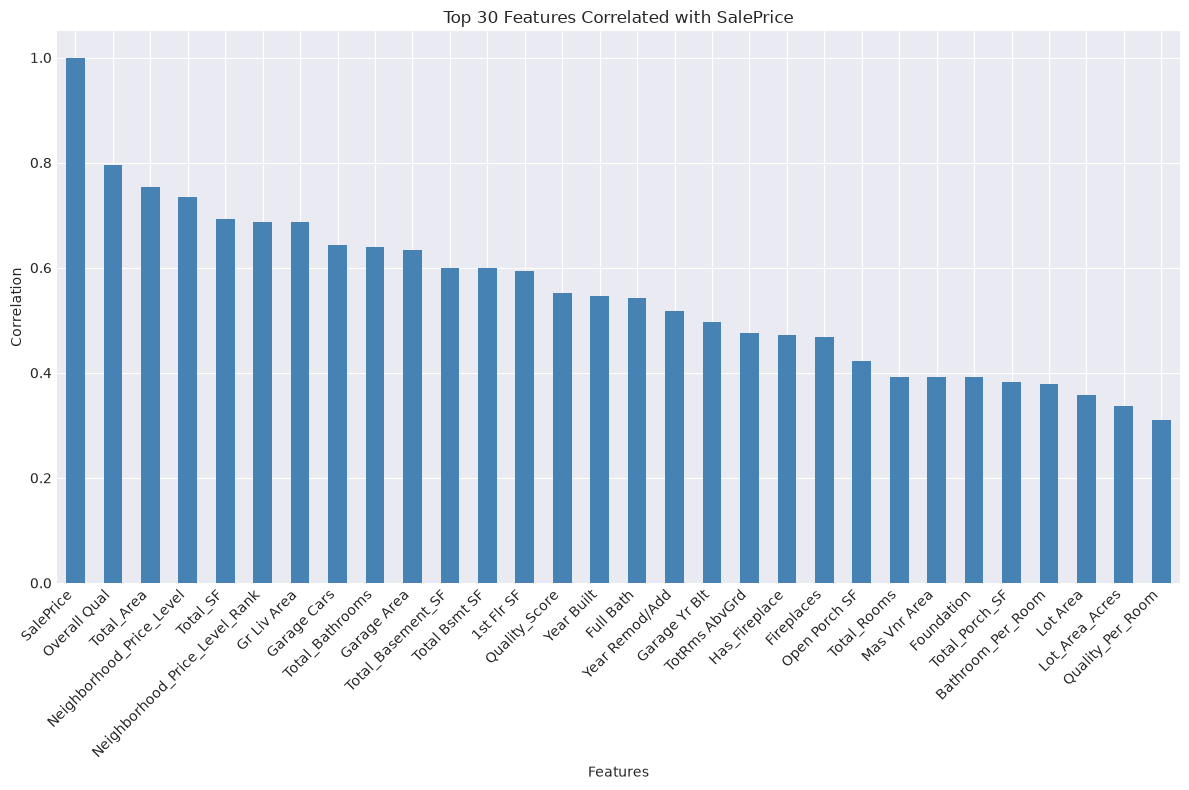


Top 10 correlations:
SalePrice                        1.000000
Overall Qual                     0.795298
Total_Area                       0.753664
Neighborhood_Price_Level         0.733763
Total_SF                         0.692126
Neighborhood_Price_Level_Rank    0.687553
Gr Liv Area                      0.687370
Garage Cars                      0.644218
Total_Bathrooms                  0.639103
Garage Area                      0.633081
Name: SalePrice, dtype: float64


In [56]:
# Create final DataFrame for correlation analysis
final_df = pd.DataFrame(X_train_scaled, columns=selected_features)
final_df['SalePrice'] = y_train.values

# Correlation with target
correlations = final_df.corr()['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlations.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 Features Correlated with SalePrice')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nTop 10 correlations:')
print(correlations.head(10))

## 9. Save Processed Data and Artifacts

In [57]:
# Save processed data
processed_df = pd.DataFrame(X_train_scaled, columns=selected_features)
processed_df['SalePrice'] = y_train.values
processed_df.to_csv('../data/processed/ames_processed_train.csv', index=False)
print("✅ Training data saved to data/processed/ames_processed_train.csv")

test_df = pd.DataFrame(X_test_scaled, columns=selected_features)
test_df['SalePrice'] = y_test.values
test_df.to_csv('../data/processed/ames_processed_test.csv', index=False)
print("✅ Test data saved to data/processed/ames_processed_test.csv")

# Save complete processed dataset
X_all = scaler.transform(selector.transform(X))
df_complete = pd.DataFrame(X_all, columns=selected_features)
df_complete['SalePrice'] = y.values
df_complete.to_csv('../data/processed/ames_processed.csv', index=False)
print("✅ Complete processed data saved to data/processed/ames_processed.csv")

# Save feature scores
feature_scores.to_csv('../models/feature_importance.csv', index=False)
print("✅ Feature scores saved to models/feature_importance.csv")

✅ Training data saved to data/processed/ames_processed_train.csv
✅ Test data saved to data/processed/ames_processed_test.csv
✅ Complete processed data saved to data/processed/ames_processed.csv
✅ Feature scores saved to models/feature_importance.csv


In [58]:
# Save artifacts for later use
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler saved to models/scaler.pkl")

with open('../models/selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)
print("✅ Selected features saved to models/selected_features.json")

joblib.dump(label_encoders, '../models/label_encoders.pkl')
print("✅ Label encoders saved to models/label_encoders.pkl")

if power_transformers:
    joblib.dump(power_transformers, '../models/power_transformers.pkl')
    print("✅ Power transformers saved to models/power_transformers.pkl")

# Save selector
joblib.dump(selector, '../models/selector.pkl')
print("✅ Selector saved to models/selector.pkl")

# Save training data for quick loading
training_data = {
    'X_train': X_train_scaled,
    'y_train': y_train.values,
    'X_test': X_test_scaled,
    'y_test': y_test.values,
    'feature_names': selected_features,
    'selector': selector,
    'scaler': scaler
}
joblib.dump(training_data, '../models/training_data.pkl')
print("✅ Training data saved to models/training_data.pkl")

✅ Scaler saved to models/scaler.pkl
✅ Selected features saved to models/selected_features.json
✅ Label encoders saved to models/label_encoders.pkl
✅ Power transformers saved to models/power_transformers.pkl
✅ Selector saved to models/selector.pkl
✅ Training data saved to models/training_data.pkl


## 10. Summary

In [59]:
print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"\nOriginal shape: {df.shape}")
print(f"Final shape: {df_complete.shape}")
print(f"Features selected: {len(selected_features)}")
print(f"Training samples: {len(X_train_scaled)}")
print(f"Test samples: {len(X_test_scaled)}")

print("\nFiles generated:")
print("  - data/processed/ames_processed.csv")
print("  - data/processed/ames_processed_train.csv")
print("  - data/processed/ames_processed_test.csv")
print("  - models/scaler.pkl")
print("  - models/selector.pkl")
print("  - models/selected_features.json")
print("  - models/feature_importance.csv")
print("  - models/label_encoders.pkl")
print("  - models/power_transformers.pkl")
print("  - models/training_data.pkl")
print("  - reports/figures/correlation_analysis.png")

print("\n✅ All artifacts are ready for Model Development notebook!")

FEATURE ENGINEERING COMPLETE

Original shape: (2930, 82)
Final shape: (2930, 51)
Features selected: 50
Training samples: 2344
Test samples: 586

Files generated:
  - data/processed/ames_processed.csv
  - data/processed/ames_processed_train.csv
  - data/processed/ames_processed_test.csv
  - models/scaler.pkl
  - models/selector.pkl
  - models/selected_features.json
  - models/feature_importance.csv
  - models/label_encoders.pkl
  - models/power_transformers.pkl
  - models/training_data.pkl
  - reports/figures/correlation_analysis.png

✅ All artifacts are ready for Model Development notebook!


In [60]:
# Quick verification
print("\n=== Verification ===")
print(f"Processed data shape: {pd.read_csv('../data/processed/ames_processed.csv').shape}")
print(f"Scaler file exists: {Path('../models/scaler.pkl').exists()}")
print(f"Selector file exists: {Path('../models/selector.pkl').exists()}")
print(f"Features file exists: {Path('../models/selected_features.json').exists()}")
print(f"Training data file exists: {Path('../models/training_data.pkl').exists()}")
print("\n✅ Everything is ready! You can now run the Model Development notebook.")


=== Verification ===
Processed data shape: (2930, 51)
Scaler file exists: True
Selector file exists: True
Features file exists: True
Training data file exists: True

✅ Everything is ready! You can now run the Model Development notebook.
